In [1]:
## modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
##
from src.data.load_data import load_raw_data

In [2]:
## style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(12,8)

In [3]:
## chargement 
train, test = load_raw_data()

In [4]:
## Comprehension
train.head()

,passenger_id,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1216,3,"Smyth, Miss. Julia",female,NaN,0,0,335432,7.7333,NaN,Q,13,NaN,NaN,1
1,699,3,"Cacic, Mr. Luka",male,38.0,0,0,315089,8.6625,NaN,S,NaN,NaN,Croatia,0
2,1267,3,"Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...",female,30.0,1,1,345773,24.1500,NaN,S,NaN,NaN,NaN,0
3,449,2,"Hocking, Mrs. Elizabeth (Eliza Needs)",female,54.0,1,3,29105,23.0000,NaN,S,4,NaN,"Cornwall / Akron, OH",1
4,576,2,"Veal, Mr. James",male,40.0,0,0,28221,13.0000,NaN,S,NaN,NaN,"Barre, Co Washington, VT",0


In [5]:
## shape 
train.shape

(850, 15)

In [6]:
## tail 
train.tail()

,passenger_id,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
845,158,1,"Hipkins, Mr. William Edward",male,55.0,0,0,680,50.000,C39,S,NaN,NaN,London / Birmingham,0
846,174,1,"Kent, Mr. Edward Austin",male,58.0,0,0,11771,29.700,B37,C,NaN,258.0,"Buffalo, NY",0
847,467,2,"Kantor, Mrs. Sinai (Miriam Sternin)",female,24.0,1,0,244367,26.000,NaN,S,12,NaN,"Moscow / Bronx, NY",1
848,1112,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.775,NaN,S,NaN,NaN,NaN,0
849,425,2,"Greenberg, Mr. Samuel",male,52.0,0,0,250647,13.000,NaN,S,NaN,19.0,"Bronx, NY",0


In [9]:
## decrible
train.describe().T

,count,mean,std,min,25%,50%,75%,max
passenger_id,850.0,662.816471,380.751936,1.0000,332.2500,676.5000,992.25,1307.0000
pclass,850.0,2.320000,0.838530,1.0000,2.0000,3.0000,3.00,3.0000
age,676.0,29.519847,14.562243,0.1667,20.0000,28.0000,37.00,80.0000
sibsp,850.0,0.522353,1.112132,0.0000,0.0000,0.0000,1.00,8.0000
parch,850.0,0.382353,0.879511,0.0000,0.0000,0.0000,0.00,9.0000
fare,849.0,34.012701,53.705779,0.0000,7.8958,14.1083,31.00,512.3292
body,73.0,165.821918,99.068487,4.0000,75.0000,166.0000,260.00,328.0000
survived,850.0,0.368235,0.482610,0.0000,0.0000,0.0000,1.00,1.0000


In [10]:
## missing value
train.isnull().sum()

passenger_id      0
pclass            0
name              0
sex               0
age             174
sibsp             0
parch             0
ticket            0
fare              1
cabin           659
embarked          1
boat            542
body            777
home.dest       386
survived          0
dtype: int64

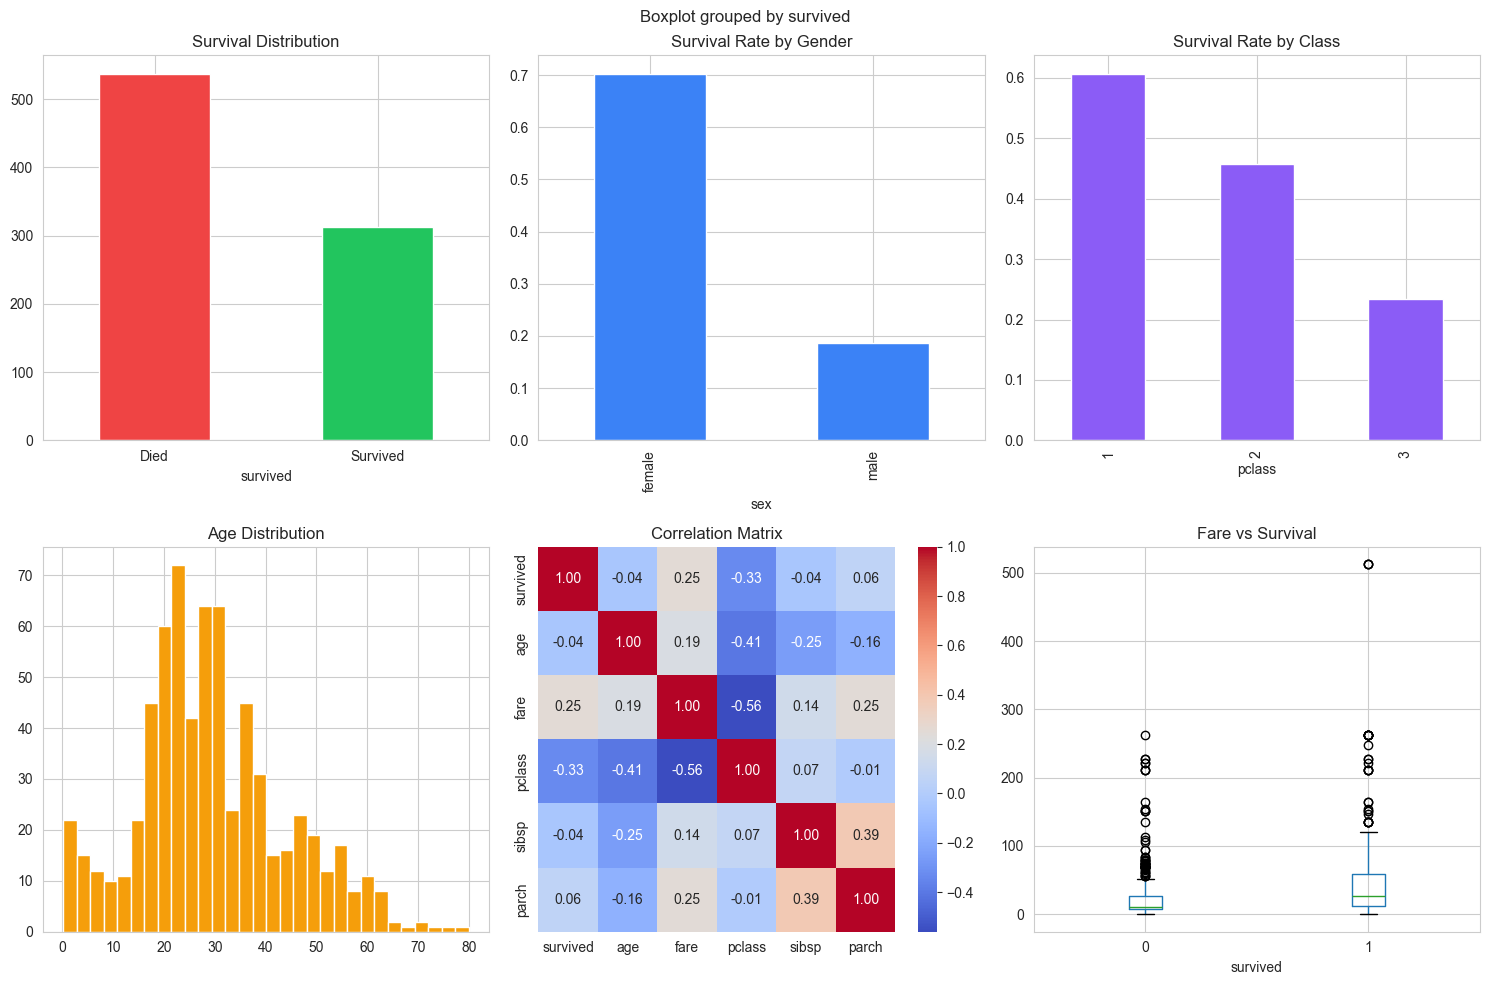

In [18]:
## Visualisations 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribution target
train['survived'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#ef4444', '#22c55e'])
axes[0,0].set_title('Survival Distribution')
axes[0,0].set_xticklabels(['Died', 'Survived'], rotation=0)

# Survival by Sex
train.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0,1], color='#3b82f6')
axes[0,1].set_title('Survival Rate by Gender')

# Survival by Class
train.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[0,2], color='#8b5cf6')
axes[0,2].set_title('Survival Rate by Class')

# Age distribution
train['age'].hist(bins=30, ax=axes[1,0], color='#f59e0b', edgecolor='white')
axes[1,0].set_title('Age Distribution')

# Correlation heatmap
numeric_cols = ['survived', 'age', 'fare', 'pclass', 'sibsp', 'parch']
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt='.2f', ax=axes[1,1], cmap='coolwarm')
axes[1,1].set_title('Correlation Matrix')

# Fare vs Survival
train.boxplot(column='fare', by='survived', ax=axes[1,2])
axes[1,2].set_title('Fare vs Survival')

plt.tight_layout()
plt.savefig('../reports/figures/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()